In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#TOI 1338 System

In [ ]:
#System Mass Calculations

#Mass of Moon
Mm = 7.342e22  # Mass of Moon (kg)=
#Mass of Earth (kg)
Me = 5.972e24
#Mass of Sun (kg)
Ms = 1.9885e30 

# Gravitational constant in units: au^3 / (Msun * day^2)
# we must use a new gravitational constant in order to use the given initial conditions and masses in the correct units (au, Msun, days)
G = 2.9591220828559093e-4


# Masses (solar masses)
MA = 1.03784970719363567  #Mass 1338A Star
MB = 2.97388770751337850e-01 #Mass 1338B Star
MP = 9.06017229632760055e-05 #Mass of 1338b (gas giant planet)
masses = np.array([MA, MB, MP])

In [ ]:
# Initial conditions for the three-body system (TOI 1338)

# Initial positions (au)
r1_0 = np.array([1.95196590778876217e-02,
                 1.32648896371446897e-04,
                 2.22880532978689296e-02])

r2_0 = np.array([-6.82335050435495666e-02,
                 -4.65900424342245798e-04,
                 -7.78747286204819755e-02])

r3_0 = np.array([3.68709659800795730e-01,
                 9.75628498103004414e-03,
                 3.02645766911772141e-01])

# Initial velocities (au/day)
v1_0 = np.array([-7.66586168788931707e-03,
                  5.45640776503903006e-05,
                  9.13006908476301365e-03])

v2_0 = np.array([ 2.67578221143398472e-02,
                 -1.90441050119945319e-04,
                 -3.18697187907663951e-02])

v3_0 = np.array([-1.61533175726252566e-02,
                  6.31089229491667655e-05,
                  2.27034214206392367e-02])

# Initial state vector
y0 = np.concatenate([r1_0, v1_0, r2_0, v2_0, r3_0, v3_0])

In [ ]:
# Define the three-body system dynamics

def three_body_derivatives(t, y, masses):
    # unpack state vector into positions and velocities
    r1 = y[0:3]
    v1 = y[3:6]

    r2 = y[6:9]
    v2 = y[9:12]

    r3 = y[12:15]
    v3 = y[15:18]

    # Relative position vectors
    r12 = r2 - r1
    r13 = r3 - r1
    r23 = r3 - r2

    r21 = -r12
    r31 = -r13
    r32 = -r23

    # Distances
    d12 = np.linalg.norm(r12)
    d13 = np.linalg.norm(r13)
    d23 = np.linalg.norm(r23)

    # Accelerations
    a1 = G * masses[1] * r12 / d12**3 + G * masses[2] * r13 / d13**3
    a2 = G * masses[0] * r21 / d12**3 + G * masses[2] * r23 / d23**3
    a3 = G * masses[0] * r31 / d13**3 + G * masses[1] * r32 / d23**3

    # Derivative of state vector
    dydt = np.concatenate([v1, a1, v2, a2, v3, a3])
    return dydt

In [ ]:
#RK4 function 
def rk4_step(f, t, y, h, masses):
    k1 = f(t, y, masses)
    k2 = f(t + h/2, y + h*k1/2, masses)
    k3 = f(t + h/2, y + h*k2/2, masses)
    k4 = f(t + h, y + h*k3, masses)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

#RK4 integration function loop
def integrate_rk4(f, y0, t0, tf, h, masses):
    n_steps = int((tf - t0) / h)

    t_values = np.zeros(n_steps + 1)
    y_values = np.zeros((n_steps + 1, len(y0)))

    t_values[0] = t0
    y_values[0] = y0

    t = t0
    y = y0.copy()

    for i in range(n_steps):
        y = rk4_step(f, t, y, h, masses)
        t += h
        t_values[i+1] = t
        y_values[i+1] = y

    return t_values, y_values

In [ ]:
#Plot settings
t0 = 0.0       # days
tf = 500  # simulate 500 days
h  = 0.1       # step size in days

t_values, y_values = integrate_rk4(three_body_derivatives, y0, t0, tf, h, masses)

# Extract trajectories
r1_traj = y_values[:, 0:3]
r2_traj = y_values[:, 6:9]
r3_traj = y_values[:, 12:15]

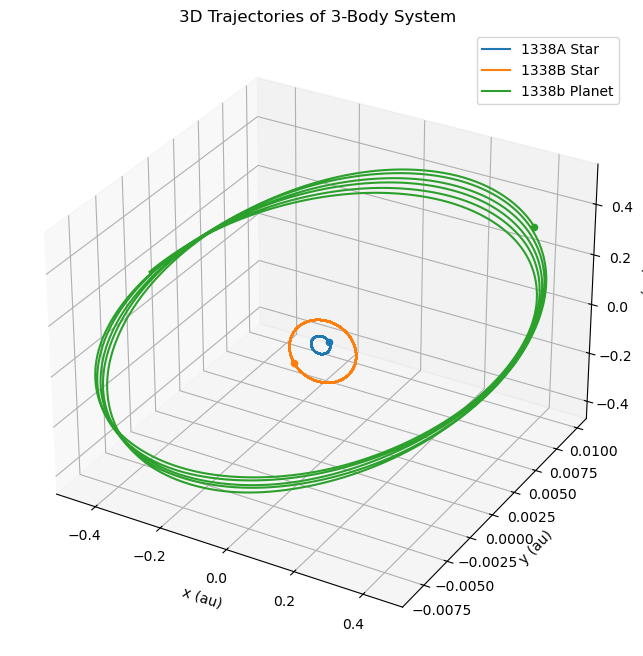

In [ ]:
# 3D plot of trajectories
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectories
ax.plot(r1_traj[:, 0], r1_traj[:, 1], r1_traj[:, 2], label='1338A Star')
ax.plot(r2_traj[:, 0], r2_traj[:, 1], r2_traj[:, 2], label='1338B Star')
ax.plot(r3_traj[:, 0], r3_traj[:, 1], r3_traj[:, 2], label='1338b Planet')

# Plot starting points
ax.scatter(r1_traj[0, 0], r1_traj[0, 1], r1_traj[0, 2], marker='o')
ax.scatter(r2_traj[0, 0], r2_traj[0, 1], r2_traj[0, 2], marker='o')
ax.scatter(r3_traj[0, 0], r3_traj[0, 1], r3_traj[0, 2], marker='o')

ax.set_xlabel('x (au)')
ax.set_ylabel('y (au)')
ax.set_zlabel('z (au)')
ax.set_title('3D Trajectories of 3-Body System')
ax.legend()

plt.show()